<a href="https://colab.research.google.com/github/Sprusheeth/AI-ML-2303A51206/blob/main/lab8(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:320: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975



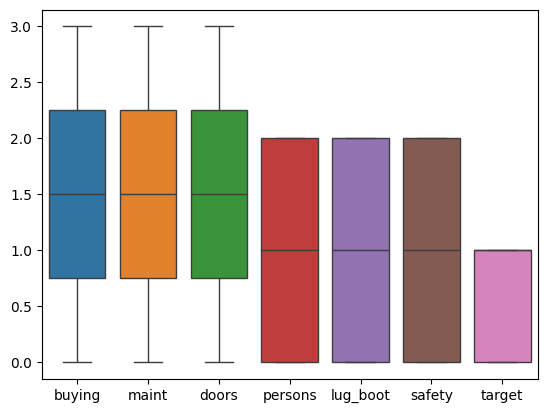

Test Accuracy: 0.8728323699421965
Confusion Matrix:
 [[148  13]
 [ 53 305]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.92      0.82       161
           1       0.96      0.85      0.90       358

    accuracy                           0.87       519
   macro avg       0.85      0.89      0.86       519
weighted avg       0.89      0.87      0.88       519

Improved Confusion Matrix:
 [[148  13]
 [ 53 305]]
Improved Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.92      0.82       161
           1       0.96      0.85      0.90       358

    accuracy                           0.87       519
   macro avg       0.85      0.89      0.86       519
weighted avg       0.89      0.87      0.88       519



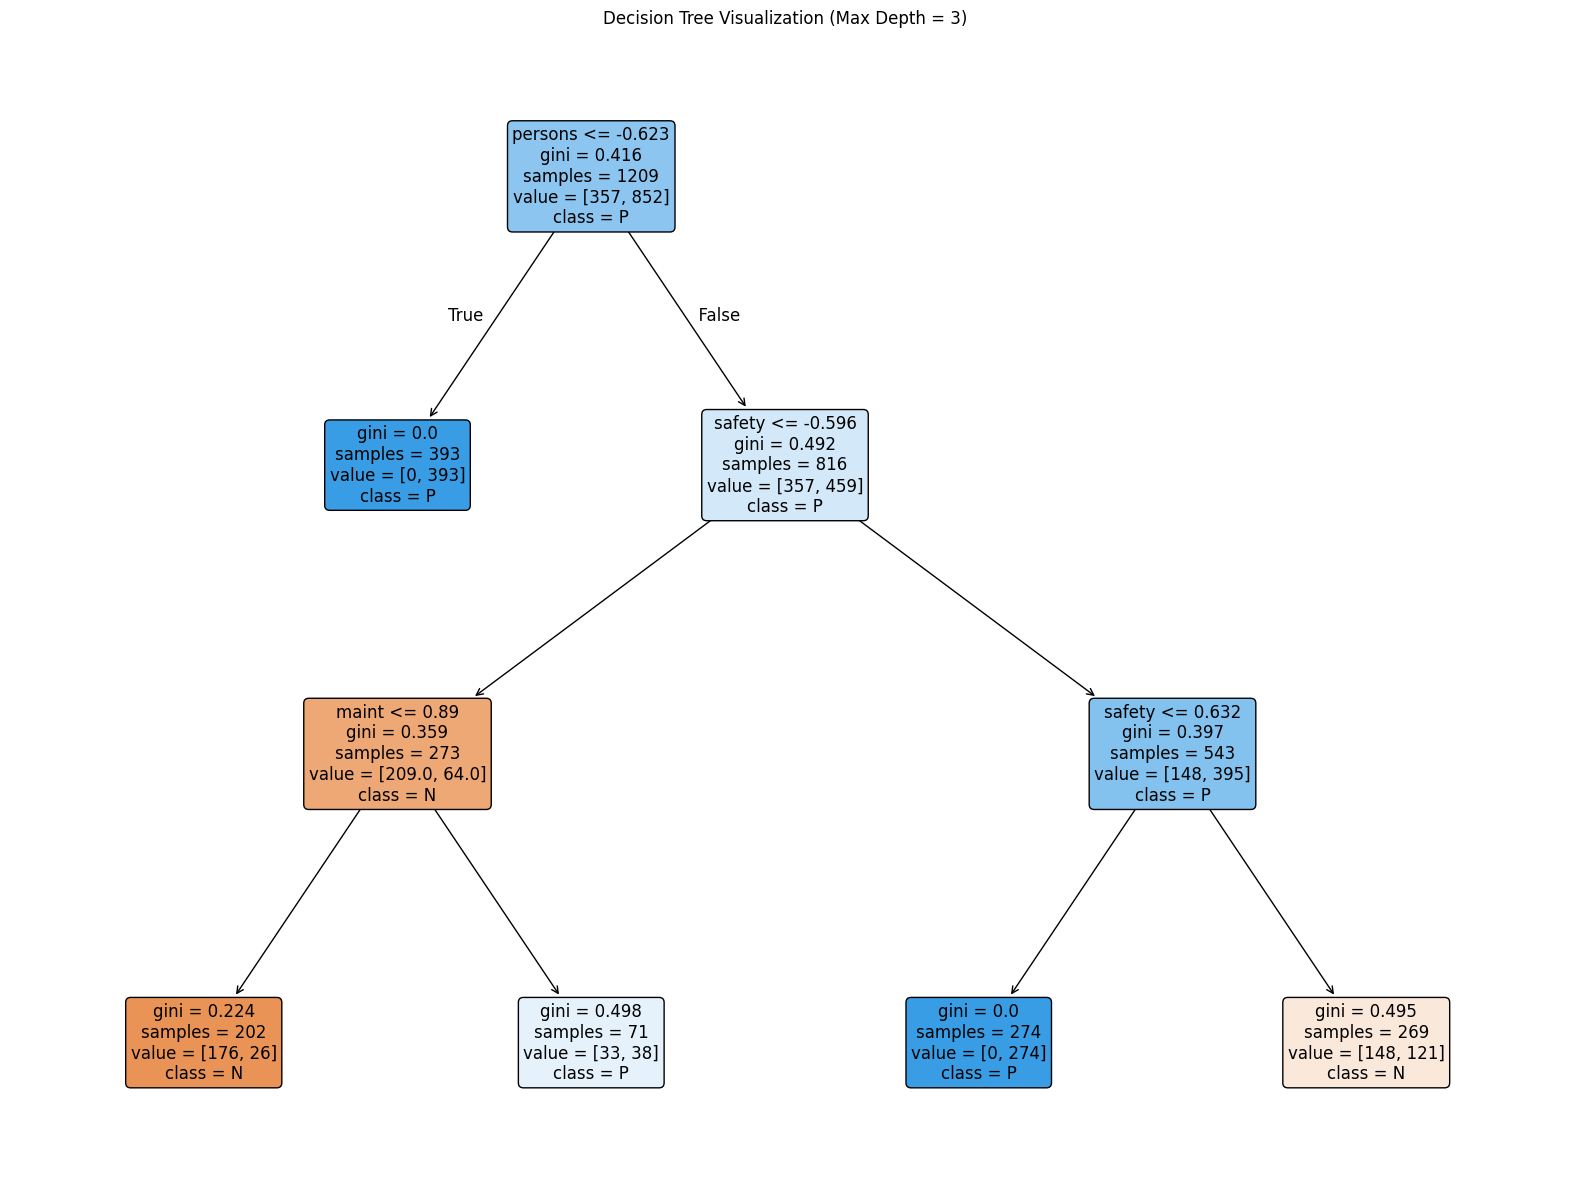

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml

data = fetch_openml('car')
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])

df.describe()

sns.boxplot(data=df.iloc[:, :10])
plt.show()

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(max_depth=3))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))
y_pred_gs = pipeline.predict(X_test)
print("Improved Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_gs))
print("Improved Classification Report:\n", metrics.classification_report(y_test, y_pred_gs))

plt.figure(figsize=(20, 15))
plot_tree(pipeline.named_steps['clf'],
          filled=True,
          feature_names=X.columns,
          class_names=le.classes_,
          rounded=True,
          fontsize=12)
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()
